# Lorenz Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Lorenz system using the multi-trajectory (Part 1) workflow.

## Governing equations

The classic Lorenz-63 dynamics are

$$
\begin{align*}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x (\rho - z) - y, \\
\dot{z} &= x y - \beta z.
\end{align*}
$$

We use $(\sigma,\rho,\beta) = (10, 28, 8/3)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (register 3D projection)
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import (
    LorenzMultiTrajectoryGLSConfig,
    generate_lorenz_dataset,
    run_lorenz_multi_trajectory_gls_experiment,
)
from mfsindy.cases.lorenz_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("examples") / "lorenz" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]




In [2]:
cfg = LorenzMultiTrajectoryGLSConfig(
    n_runs=25,
    results_dir=str(RESULTS_DIR),
    results_filename="lorenz_part1_errors.csv",
)

print(
    f"Running Part 1 Lorenz experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_lorenz_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()/27
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)
print(mae_summary)
print(l0_summary)


Running Part 1 Lorenz experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Lorenz MF:   0%|          | 0/25 [00:00<?, ?it/s]

MODEL HF:
(x0)' =  0.000
(x1)' =  0.000
(x2)' = -2.684 x2 +  1.056 x0 x1
MODEL LF:
(x0)' =  36.805 x0 +  8.679 x1 + -1.920 x0 x2
(x1)' =  4.519 x0 + -0.612 x2
(x2)' = -3.670 x0 + -2.938 x2 +  1.208 x0 x1
MODEL MF:
(x0)' =  36.944 x0 +  8.617 x1 + -1.939 x0 x2
(x1)' =  4.510 x0 + -0.252 x2
(x2)' = -3.594 x0 + -2.837 x2 +  1.150 x0 x1


Monte Carlo Lorenz MF:   4%|▍         | 1/25 [00:12<05:10, 12.95s/it]

MODEL MFW:
(x0)' = -10.245 x0 +  9.989 x1
(x1)' =  2.931 x0
(x2)' = -2.698 x2 +  1.086 x0 x1
MODEL HF:
(x0)' =  0.000
(x1)' =  4.363 x0
(x2)' = -2.738 x2 +  1.031 x0 x1
MODEL LF:
(x0)' =  15.746 x0 + -1.065 x0 x2
(x1)' =  40.599 x0 + -1.568 x0 x2
(x2)' = -2.699 x0 +  1.200 x1 + -3.656 x2 +  1.005 x0^2
MODEL MF:
(x0)' =  13.118 x0 +  2.238 x1 + -0.976 x0 x2
(x1)' =  40.169 x0 + -1.534 x0 x2
(x2)' = -3.314 x0 +  1.257 x1 + -3.442 x2 +  0.984 x0^2


...

MODEL MFW:
(x0)' = -9.779 x0 +  9.929 x1
(x1)' =  27.989 x0 + -0.851 x1 + -1.017 x0 x2
(x2)' = -2.688 x2 +  1.005 x0 x1
MODEL HF:
(x0)' =  0.000
(x1)' =  3.177 x0
(x2)' = -2.629 x2 +  1.008 x0 x1
MODEL LF:
(x0)' =  25.660 x0 + -18.676 x1 + -1.393 x0 x2 +  1.219 x1 x2
(x1)' =  6.508 x0 + -2.260 x1
(x2)' = -41.699 x0 + -1.407 x1 + -3.448 x2 +  0.760 x0 x1 +  1.798 x0 x2
MODEL MF:
(x0)' =  22.872 x0 + -15.621 x1 + -1.288 x0 x2 +  1.118 x1 x2
(x1)' =  6.196 x0 + -2.483 x1
(x2)' = -40.156 x0 + -1.678 x1 + -3.325 x2 +  0.741 x0 x1 +  1.702 x0 x2


Monte Carlo Lorenz MF:  96%|█████████▌| 24/25 [16:16<01:17, 77.74s/it]

MODEL MFW:
(x0)' = -9.907 x0 +  9.704 x1
(x1)' =  4.527 x0 + -1.026 x1
(x2)' = -2.649 x2 +  1.012 x0 x1
MODEL HF:
(x0)' =  0.000
(x1)' = -0.508 x1^2
(x2)' = -2.748 x2 +  1.077 x0 x1
MODEL LF:
(x0)' = -4.638 x0 +  9.077 x1
(x1)' =  23.825 x0 +  21.240 x1 + -0.934 x0 x2 + -0.861 x1 x2
(x2)' =  19.581 x0 +  1.381 x1 + -1.691 x2 + -0.977 x0 x2
MODEL MF:
(x0)' = -5.379 x0 +  8.985 x1
(x1)' =  28.553 x0 +  17.973 x1 + -1.130 x0 x2 + -0.715 x1 x2
(x2)' =  22.209 x0 +  1.115 x1 + -1.744 x2 + -1.101 x0 x2


Monte Carlo Lorenz MF: 100%|██████████| 25/25 [18:03<00:00, 43.36s/it]

MODEL MFW:
(x0)' = -10.225 x0 +  10.059 x1
(x1)' =  4.168 x0
(x2)' = -2.737 x2 +  1.049 x0 x1
         median       q25       q75
model                              
HF     0.062888  0.060066  0.064656
LF     0.091206  0.076447  0.113420
MF     0.087579  0.070122  0.109633
MF_w   0.033541  0.003904  0.034944
         median       q25       q75
model                              
HF     0.021164  0.015873  0.026455
LF     0.031746  0.026455  0.031746
MF     0.031746  0.026455  0.031746
MF_w   0.005291  0.000000  0.005291


### Trajectory snapshot
Preview noisy LF/HF trajectories vs. a long clean reference.


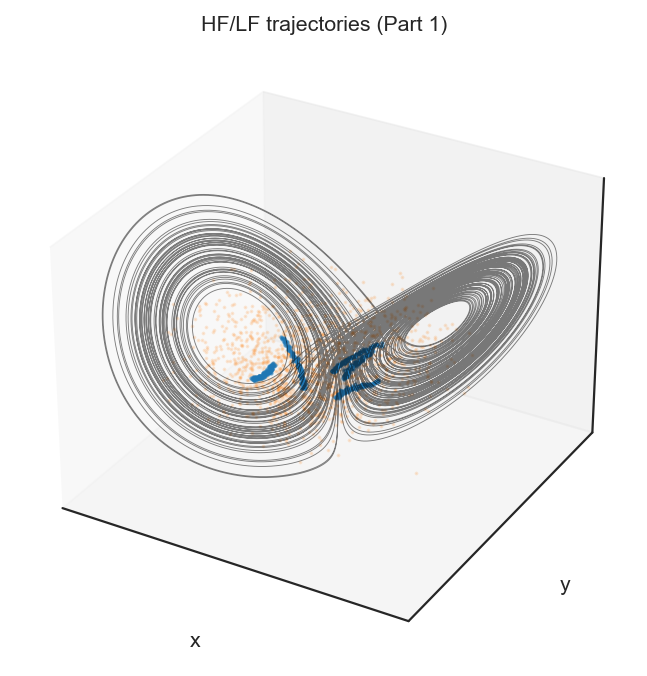

In [3]:
X_hf_batch, t_train, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base + 5,
)
X_lf_batch, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base + 125,
)
X_clean, _, _ = generate_lorenz_dataset(
    n_traj=1,
    T=cfg.T_true,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)

fig = plt.figure(figsize=(5, 5), dpi=160)
ax = fig.add_subplot(111, projection="3d")
ax.set_title("HF/LF trajectories (Part 1)")

for traj in X_lf_batch[: min(15, len(X_lf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.15,
        color=COLORS_MODELS["LF"],
        markersize=1.4,
    )
for traj in X_hf_batch[: min(5, len(X_hf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.6,
        color=COLORS_MODELS["HF"],
        markersize=1.8,
    )
ax.plot(
    X_clean[0][:, 0],
    X_clean[0][:, 1],
    X_clean[0][:, 2],
    color="black",
    linewidth=0.4,
    alpha=0.5,
)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.grid(False)
plt.show()



### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.


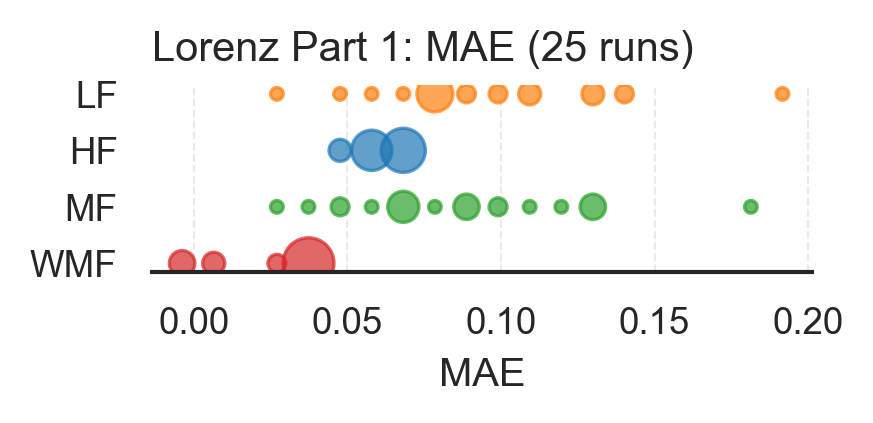

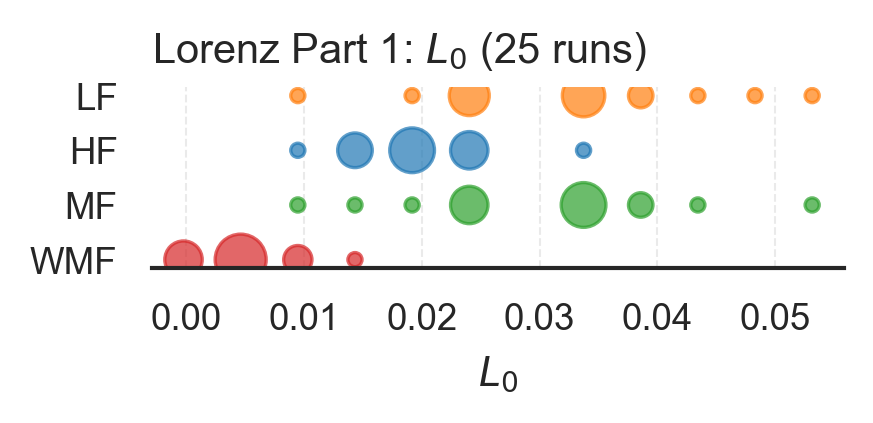

In [4]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    title=f"Lorenz Part 1: MAE ({cfg.n_runs} runs)",
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    title=f"Lorenz Part 1: $L_0$ ({cfg.n_runs} runs)",
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

